# 04 - Feature-Space OOD Detection: Mahalanobis and KNN

Notebooks 02 and 03 scored out-of-distribution (OOD) inputs using the classifier's
**logit / softmax output** (MSP, ODIN, Energy). Those scores all answer *"which of my
known classes does this look like, and how confidently?"* -- which is fundamentally a
**relative** comparison between classes. A softmax layer has no way to say "none of the
above": even a wildly unfamiliar input gets forced into some class, sometimes with high
confidence, because softmax normalizes whatever logits it receives.

This notebook instead scores inputs in the **penultimate feature space** -- the
activation vector feeding the final linear layer, *before* it gets collapsed into 10
logits. Feature space still has room to express "this doesn't look like anything I've
seen," because we can directly measure a *distance* from the input's features to the
training data's feature clusters, rather than a probability that must sum to 1.

Two feature-space methods, implemented from scratch:

1. **Class-conditional Mahalanobis distance** (Lee, Lee, Lee & Shin, 2018,
   *"A Simple Unified Framework for Detecting Out-of-Distribution Samples and
   Adversarial Attacks"*, NeurIPS, arXiv:1807.03888): fit a per-class Gaussian
   (mean `mu_c`, shared covariance `Sigma`) over training features, then score a new
   input by its distance to the *nearest* class mean.
2. **KNN-distance** (Sun, Ming, Zhu & Li, 2022, *"Out-of-Distribution Detection with
   Deep Nearest Neighbors"*, ICML, arXiv:2204.06507): skip the Gaussian assumption
   entirely -- score a new input by its raw distance to the k-th nearest training
   feature, non-parametrically.

Both are then compared against a logit-space **MSP baseline** (recomputed here, on the
same trained model, for an apples-to-apples comparison) using **AUROC**. Same setup as
notebooks 02/03: MNIST is in-distribution (ID), FashionMNIST is out-of-distribution
(OOD).


## Setup and reproducibility

Imports, a fixed seed, `DEVICE = cpu`, and the repo's `data/` directory resolved by
walking up from the current working directory until we find `pyproject.toml`. Both
MNIST and FashionMNIST are already downloaded there, so we pass `download=False`.


In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cpu")

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / "pyproject.toml").exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / "data")
print("data root:", DATA_ROOT)
print("device:", DEVICE)

data root: c:\Users\abero\dev\applied_learning\data
device: cpu


## Data: MNIST (ID) vs FashionMNIST (OOD)

A class-balanced MNIST training subset (600 images/class = 6000 total) trains the CNN
**and** becomes the "fit set" for both feature-space methods (per-class means +
covariance for Mahalanobis, the reference bank for KNN). Balanced classes matter here:
Mahalanobis needs a reasonable number of points per class to estimate stable per-class
means. Eval sets are MNIST-test (ID) and FashionMNIST-test (OOD), same size on each
side so AUROC isn't biased by class imbalance.


In [2]:
N_TRAIN_PER_CLASS = 600     # -> 6000 MNIST training images (the fit set)
N_EVAL_ID = 1500            # MNIST test subset (ID)
N_EVAL_OOD = 1500           # FashionMNIST test subset (OOD)

transform = transforms.Compose([
    transforms.ToTensor(),                              # -> [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(DATA_ROOT, train=True, download=False, transform=transform)
mnist_test = datasets.MNIST(DATA_ROOT, train=False, download=False, transform=transform)
fmnist_test = datasets.FashionMNIST(DATA_ROOT, train=False, download=False, transform=transform)


def class_balanced_subset(ds, n_per_class, num_classes=10):
    labels = np.array(ds.targets)
    idxs = []
    for c in range(num_classes):
        idxs.extend(np.where(labels == c)[0][:n_per_class])
    xs = torch.stack([ds[int(i)][0] for i in idxs])
    ys = torch.tensor([ds[int(i)][1] for i in idxs])
    return xs, ys


def plain_subset(ds, n):
    xs = torch.stack([ds[i][0] for i in range(n)])
    ys = torch.tensor([ds[i][1] for i in range(n)])
    return xs, ys


X_fit, y_fit = class_balanced_subset(mnist_train, N_TRAIN_PER_CLASS)   # fit set (MNIST-train)
X_id, y_id = plain_subset(mnist_test, N_EVAL_ID)                       # ID eval (MNIST-test)
X_ood, _ = plain_subset(fmnist_test, N_EVAL_OOD)                       # OOD eval (FashionMNIST-test)

print("fit set (MNIST-train):", tuple(X_fit.shape))
print("ID eval (MNIST-test):", tuple(X_id.shape))
print("OOD eval (FashionMNIST-test):", tuple(X_ood.shape))

C:\Users\abero\AppData\Local\Temp\ipykernel_10356\3177481189.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(ds.targets)


fit set (MNIST-train): (6000, 1, 28, 28)
ID eval (MNIST-test): (1500, 1, 28, 28)
OOD eval (FashionMNIST-test): (1500, 1, 28, 28)


## A small CNN that exposes its penultimate features

Same two-conv-block architecture as notebook 03's `SmallCNN`, but `forward` now
returns **both** the 64-dim penultimate feature vector (the input to the final linear
layer) and the 10-way logits -- so every downstream score can use either the feature
vector or the logits from a single forward pass.


In [3]:
class SmallCNN(nn.Module):
    def __init__(self, feat_dim=64, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, feat_dim)
        self.fc2 = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        h = self.pool(F.relu(self.conv1(x)))    # (B, 16, 14, 14)
        h = self.pool(F.relu(self.conv2(h)))    # (B, 32, 7, 7)
        h = h.flatten(1)
        feats = F.relu(self.fc1(h))             # penultimate features, (B, feat_dim)
        logits = self.fc2(feats)                # raw logits, (B, n_classes)
        return feats, logits


torch.manual_seed(SEED)
model = SmallCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SmallCNN parameters: {n_params}")

SmallCNN parameters: 105866


## Train on the MNIST fit set

Three epochs of Adam over the 6000-image fit set, cross-entropy on the logits. The
feature head is trained only implicitly -- there is no dedicated feature-space loss,
which is exactly the point of these post-hoc methods: they reuse an ordinarily trained
classifier's internal representation, no special training required.


In [4]:
BATCH = 128
EPOCHS = 3

fit_loader = DataLoader(TensorDataset(X_fit, y_fit), batch_size=BATCH, shuffle=True)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

t0 = time.time()
model.train()
for ep in range(EPOCHS):
    total_loss = total_n = 0
    for x, y in fit_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        _, logits = model(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
    print(f"epoch {ep + 1}/{EPOCHS}  loss={total_loss / total_n:.4f}")
print(f"training time: {time.time() - t0:.1f}s")

# Sanity check: ID test accuracy should be high before we trust any score from this model.
model.eval()
with torch.no_grad():
    _, id_logits_check = model(X_id.to(DEVICE))
    id_acc = (id_logits_check.argmax(1).cpu() == y_id).float().mean().item()
print(f"MNIST (ID) test accuracy: {id_acc * 100:.2f}%")
assert id_acc > 0.90, "sanity check failed: MNIST test accuracy should exceed 90%"


epoch 1/3  loss=1.0432


epoch 2/3  loss=0.2650


epoch 3/3  loss=0.1710
training time: 6.9s
MNIST (ID) test accuracy: 93.33%


## Extract features + logits for the fit set and both eval sets

One forward pass per set, in eval mode with no gradients. `fit_feats`/`fit_labels`
become the reference data both feature-space methods are fit on; `id_feats`/`ood_feats`
and `id_logits`/`ood_logits` are what gets scored.


In [5]:
@torch.no_grad()
def extract(x, batch_size=256):
    model.eval()
    feats_all, logits_all = [], []
    for i in range(0, x.size(0), batch_size):
        feats, logits = model(x[i:i + batch_size].to(DEVICE))
        feats_all.append(feats)
        logits_all.append(logits)
    return torch.cat(feats_all).numpy(), torch.cat(logits_all).numpy()


fit_feats, _ = extract(X_fit)
fit_labels = y_fit.numpy()
id_feats, id_logits = extract(X_id)
ood_feats, ood_logits = extract(X_ood)

print("fit features  (MNIST-train):", fit_feats.shape)
print("ID features   (MNIST-test):", id_feats.shape)
print("OOD features  (FashionMNIST-test):", ood_feats.shape)

fit features  (MNIST-train): (6000, 64)
ID features   (MNIST-test): (1500, 64)
OOD features  (FashionMNIST-test): (1500, 64)


## Method 1: Class-conditional Mahalanobis distance (Lee et al., 2018)

For each MNIST digit class `c`, fit a Gaussian over the fit-set features of that class:
mean `mu_c`, and a single **shared (tied) covariance** `Sigma` pooled across all 10
classes (not a separate covariance per class -- that would need far more data per class
than we have here, and Lee et al. show the tied version works just as well in practice).

A new input's score is its (negative) Mahalanobis distance to the *closest* class mean:

```
score(x) = max_c  -(f(x) - mu_c)^T Sigma^-1 (f(x) - mu_c)
```

Higher score (smaller distance) = more in-distribution. We add a small ridge
(`1e-6 * I`) to `Sigma` before inverting, standard practice for numerical stability
when a covariance estimate is near-singular.


In [6]:
N_CLASSES = 10
FEAT_DIM = fit_feats.shape[1]
RIDGE = 1e-6

class_means = np.zeros((N_CLASSES, FEAT_DIM))
centered = np.zeros_like(fit_feats)
for c in range(N_CLASSES):
    mask = fit_labels == c
    class_means[c] = fit_feats[mask].mean(axis=0)
    centered[mask] = fit_feats[mask] - class_means[c]

# Shared (tied) covariance across all classes.
shared_cov = (centered.T @ centered) / fit_feats.shape[0]
shared_cov_inv = np.linalg.inv(shared_cov + RIDGE * np.eye(FEAT_DIM))


def mahalanobis_score(feats):
    """Higher = more in-distribution (closer to its nearest class mean)."""
    best = np.full(feats.shape[0], -np.inf)
    for c in range(N_CLASSES):
        diff = feats - class_means[c]
        d2 = np.einsum("ij,jk,ik->i", diff, shared_cov_inv, diff)   # squared Mahalanobis dist
        best = np.maximum(best, -d2)
    return best


maha_id = mahalanobis_score(id_feats)
maha_ood = mahalanobis_score(ood_feats)
print(f"Mahalanobis score  ID  mean={maha_id.mean():.2f}  OOD mean={maha_ood.mean():.2f}")
print("(less negative / larger = more in-distribution)")

Mahalanobis score  ID  mean=-46.29  OOD mean=-98.50
(less negative / larger = more in-distribution)


## Method 2: KNN-distance (Sun et al., 2022)

Drop the Gaussian assumption entirely. L2-normalize every feature vector (so distance
depends on direction, not magnitude), treat the fit-set features as a **reference
bank**, and score a new input by its distance to the **k-th nearest neighbor** in that
bank:

```
score(x) = -dist_k(f(x), bank)
```

Higher score (smaller k-th-neighbor distance) = more in-distribution. `k=50` here
(Sun et al. use k in a similar range on larger benchmarks) -- a single outlier
neighbor can't fool the score, since we need the k-th closest, not the 1st.


In [7]:
K = 50


def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


bank = l2_normalize(fit_feats)
knn_index = NearestNeighbors(n_neighbors=K, metric="euclidean").fit(bank)


def knn_score(feats):
    dists, _ = knn_index.kneighbors(l2_normalize(feats))
    kth_dist = dists[:, -1]   # distance to the K-th nearest neighbor
    return -kth_dist          # higher = more in-distribution


knn_id = knn_score(id_feats)
knn_ood = knn_score(ood_feats)
print(f"KNN(k={K}) score  ID  mean={knn_id.mean():.4f}  OOD mean={knn_ood.mean():.4f}")
print("(less negative / larger = more in-distribution)")

KNN(k=50) score  ID  mean=-0.2400  OOD mean=-0.3568
(less negative / larger = more in-distribution)


## Baseline: MSP (logit space)

Recomputed here, on this notebook's own trained model, for a direct apples-to-apples
comparison against the two feature-space scores above (notebook 02 covers MSP, and
notebook 03 covers Energy/ODIN, in far more depth -- this is just the reference point
feature-space methods need to beat).


In [8]:
msp_id = F.softmax(torch.from_numpy(id_logits), dim=1).max(dim=1).values.numpy()
msp_ood = F.softmax(torch.from_numpy(ood_logits), dim=1).max(dim=1).values.numpy()
print(f"MSP score  ID  mean={msp_id.mean():.4f}  OOD mean={msp_ood.mean():.4f}")

MSP score  ID  mean=0.9098  OOD mean=0.6266


## AUROC: feature space vs logit space

Same convention as notebooks 02/03: label `1` = ID (MNIST), label `0` = OOD
(FashionMNIST); every score above is already oriented so **higher = more
in-distribution**, so `roc_auc_score(labels, score) > 0.5` means the method is doing
its job.


In [9]:
def auroc(id_scores, ood_scores):
    labels = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    scores = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(labels, scores)


results = {
    "MSP (logit, baseline)": auroc(msp_id, msp_ood),
    "Mahalanobis (feature)": auroc(maha_id, maha_ood),
    f"KNN k={K} (feature)": auroc(knn_id, knn_ood),
}

print("AUROC (ID=MNIST vs OOD=FashionMNIST, higher is better, 0.5=random):")
for name, score in results.items():
    print(f"  {name:24s} {score:.4f}")

AUROC (ID=MNIST vs OOD=FashionMNIST, higher is better, 0.5=random):
  MSP (logit, baseline)    0.8848
  Mahalanobis (feature)    0.8885
  KNN k=50 (feature)       0.9486


## Chart 1: AUROC bar chart

The headline comparison -- both feature-space methods against the logit-space MSP
baseline.


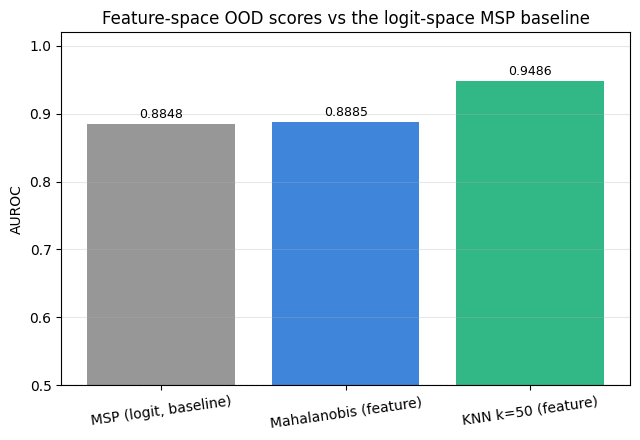

In [10]:
names = list(results.keys())
values = list(results.values())
colors = ["#8c8c8c", "#2a78d6", "#1baf7a"]   # baseline=gray, feature methods=categorical blue/aqua

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(names, values, color=colors, alpha=0.9)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.004, f"{val:.4f}",
             ha="center", va="bottom", fontsize=9)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("AUROC")
ax.set_title("Feature-space OOD scores vs the logit-space MSP baseline")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=8)
plt.tight_layout()
plt.show()

## Chart 2: PCA of penultimate features -- ID vs OOD

A 2D PCA projection of the eval-set feature vectors (fit on the combined ID+OOD points
so both project into the same coordinate frame). This is just a visualization aid --
both OOD methods above score in the full 64-dim space, not this 2D projection -- but it
gives an intuitive picture of *why* a feature-distance score can separate ID from OOD
even where a softmax-based score struggles: the two populations occupy visibly
different regions of feature space.


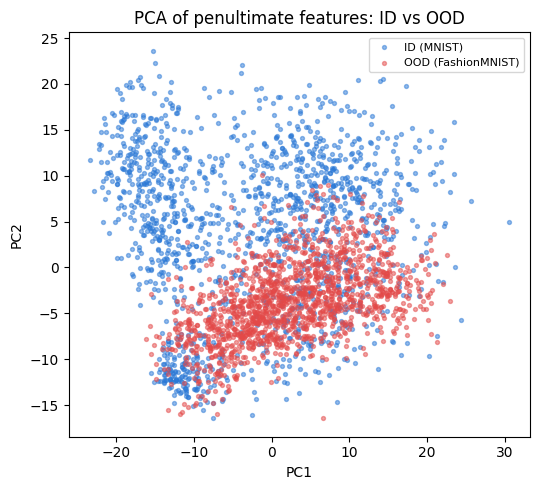

explained variance ratio (PC1, PC2): 0.298, 0.182


In [11]:
combined = np.concatenate([id_feats, ood_feats], axis=0)
pca = PCA(n_components=2, random_state=SEED)
combined_2d = pca.fit_transform(combined)
id_2d = combined_2d[:len(id_feats)]
ood_2d = combined_2d[len(id_feats):]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(id_2d[:, 0], id_2d[:, 1], s=8, alpha=0.5, color="#2a78d6", label="ID (MNIST)")
ax.scatter(ood_2d[:, 0], ood_2d[:, 1], s=8, alpha=0.5, color="#e34948", label="OOD (FashionMNIST)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of penultimate features: ID vs OOD")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_[0]:.3f}, "
      f"{pca.explained_variance_ratio_[1]:.3f}")

## Takeaways

1. **Distance beats confidence here.** Both feature-space scores look at *where a point
   sits relative to the training data's feature clusters*, not at how the classifier's
   final linear layer chooses to rank 10 classes. An OOD input can land far from every
   MNIST class cluster in feature space even while the classifier, downstream of that
   same feature vector, still outputs a confidently-peaked (and wrong) softmax --
   softmax has no way to represent "none of the above," but a distance does.

2. **Mahalanobis assumes unimodal Gaussian clusters per class.** That is a strong
   assumption, but it buys a cheap closed-form score (one small matrix inverted once)
   and works well when the assumption roughly holds, as it does for a CNN's late-layer
   features on a clean dataset like MNIST.

3. **KNN drops the Gaussian assumption entirely.** It costs more at eval time (a
   nearest-neighbor search against the whole reference bank per query) but makes no
   parametric assumption about the shape of each class's feature cluster --
   Sun et al. (2022) show this matters on real-world benchmarks where per-class
   features are not well described by a single Gaussian.

4. **This ID/OOD pair (MNIST vs. FashionMNIST) is an easy case** -- as in notebooks
   02/03, digits and clothing are visually very different, so most methods score well.
   The gap between feature-space and logit-space methods tends to widen on harder,
   closer OOD pairs (e.g. MNIST vs. KMNIST/EMNIST).
